# 보안 로그 위험도 분류 Baseline (XGBoost)

공식 Baseline 구조를 그대로 따르되 모델만 XGBoost으로 교체한 버전입니다.

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')
%matplotlib inline

print('XGBoost baseline 라이브러리 불러오기 완료')

XGBoost baseline 라이브러리 불러오기 완료


## 2. 기본 설정 및 파일 경로 지정

In [2]:
TRAIN_PATH            = 'security_log_train.csv'
TEST_PATH             = 'security_log_test.csv'
SAMPLE_SUBMISSION_PATH= 'sample_submission.csv'
OUTPUT_PATH           = 'submission.csv'
RANDOM_STATE          = 42

print('설정 완료')

설정 완료


## 3. 데이터 불러오기

In [3]:
train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print('train shape:', train.shape)
print('test  shape:', test.shape)
print('sample_submission shape:', sample_submission.shape)

train shape: (472972, 3)
test  shape: (1418916, 2)
sample_submission shape: (1418916, 2)


## 4. 기본 EDA

In [4]:
# 결측치 확인
print('[train 결측치]')
print(train.isnull().sum())
print()
print('[test 결측치]')
print(test.isnull().sum())

[train 결측치]
id          0
level       0
full_log    0
dtype: int64

[test 결측치]
id          0
full_log    0
dtype: int64


In [5]:
# 결측치 처리
train['full_log'] = train['full_log'].fillna('')
test['full_log']  = test['full_log'].fillna('')

n_missing = train['level'].isnull().sum()
if n_missing > 0:
    print(f'level 결측치 {n_missing}개 제거')
    train = train.dropna(subset=['level']).reset_index(drop=True)
else:
    print('level 결측치 없음 (정상)')

train['level'] = train['level'].astype(int)

level 결측치 없음 (정상)


[level별 데이터 개수]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64


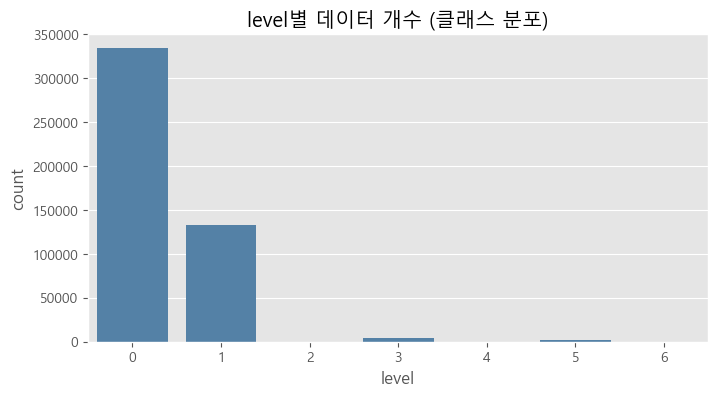

In [6]:
# level 분포 확인
level_counts = train['level'].value_counts().sort_index()
print('[level별 데이터 개수]')
print(level_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=level_counts.index, y=level_counts.values, color='steelblue')
plt.title('level별 데이터 개수 (클래스 분포)')
plt.xlabel('level')
plt.ylabel('count')
plt.show()

[train 로그 길이 통계]
count    472972.000000
mean        473.361624
std         317.267954
min           7.000000
25%         204.000000
50%         423.000000
75%         689.000000
max       64106.000000
Name: log_length, dtype: float64


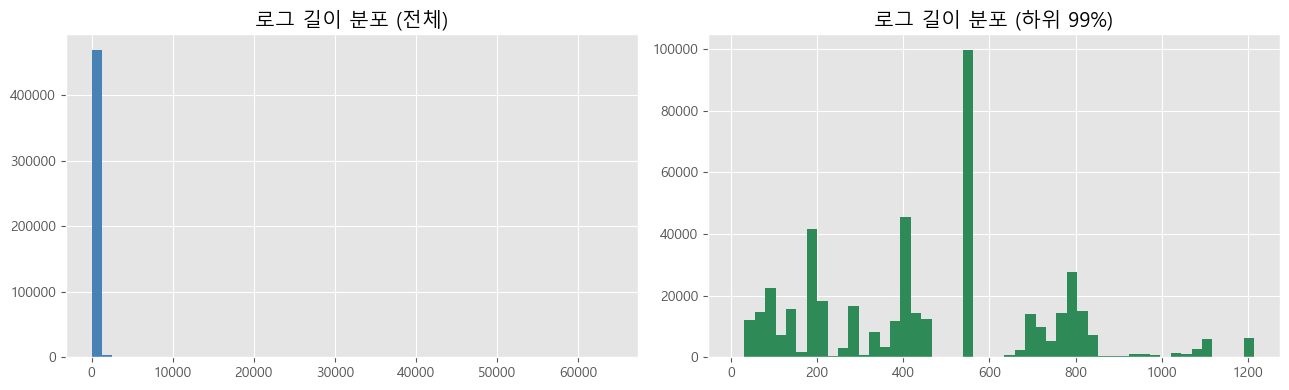

In [7]:
# 로그 길이 분석 (EDA)
train['log_length'] = train['full_log'].str.len()
test['log_length']  = test['full_log'].str.len()

print('[train 로그 길이 통계]')
print(train['log_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train['log_length'], bins=50, color='steelblue')
axes[0].set_title('로그 길이 분포 (전체)')
upper = train['log_length'].quantile(0.99)
axes[1].hist(train.loc[train['log_length'] <= upper, 'log_length'], bins=50, color='seagreen')
axes[1].set_title('로그 길이 분포 (하위 99%)')
plt.tight_layout()
plt.show()

## 5. 학습/검증 데이터 분리

In [8]:
train_model = train.copy()

X = train_model['full_log']
y = train_model['level']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

X_train: (378377,)
X_valid: (94595,)


## 6. TF-IDF 벡터화

In [9]:
# baseline과 동일한 TF-IDF 설정
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train)   # 학습 데이터로만 fit
X_valid_tfidf = tfidf.transform(X_valid)        # 검증은 transform만

print('X_train_tfidf shape:', X_train_tfidf.shape)
print('X_valid_tfidf shape:', X_valid_tfidf.shape)

X_train_tfidf shape: (378377, 5000)
X_valid_tfidf shape: (94595, 5000)


## 7. XGBoost 모델 학습

In [10]:
labels_sorted = sorted(train['level'].unique())
num_classes   = len(labels_sorted)

print('라벨 목록:', labels_sorted)
print('클래스 개수:', num_classes)

라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
클래스 개수: 7


In [11]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train_tfidf, y_train)
print('XGBoost 학습 완료')

XGBoost 학습 완료


## 8. 검증 데이터 평가

In [12]:
valid_pred = model.predict(X_valid_tfidf)

accuracy    = accuracy_score(y_valid, valid_pred)
macro_f1    = f1_score(y_valid, valid_pred, labels=labels_sorted, average='macro', zero_division=0)
weighted_f1 = f1_score(y_valid, valid_pred, labels=labels_sorted, average='weighted', zero_division=0)

print('Accuracy   :', round(accuracy, 4))
print('Macro F1   :', round(macro_f1, 4))
print('Weighted F1:', round(weighted_f1, 4))
print()
target_names = [f'level {l}' for l in labels_sorted]
print(classification_report(y_valid, valid_pred, labels=labels_sorted,
                             target_names=target_names, zero_division=0))

Accuracy   : 0.998
Macro F1   : 0.8042
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       0.00      0.00      0.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       0.86      0.78      0.80     94595
weighted avg       1.00      1.00      1.00     94595



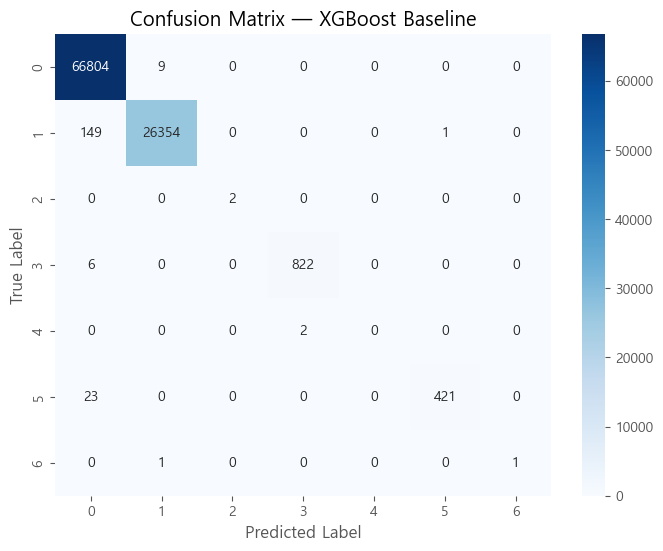

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_valid, valid_pred, labels=labels_sorted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title('Confusion Matrix — XGBoost Baseline')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. 전체 데이터로 최종 모델 학습 및 test 예측

In [14]:
X_all = train_model['full_log']
y_all = train_model['level']

final_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)
X_all_tfidf  = final_tfidf.fit_transform(X_all)
X_test_tfidf = final_tfidf.transform(test['full_log'])

print('X_all_tfidf  shape:', X_all_tfidf.shape)
print('X_test_tfidf shape:', X_test_tfidf.shape)

X_all_tfidf  shape: (472972, 5000)
X_test_tfidf shape: (1418916, 5000)


In [15]:
final_model = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
final_model.fit(X_all_tfidf, y_all)

test_pred_basic = final_model.predict(X_test_tfidf)
print('test 예측 완료')
print('예측 level 분포:', pd.Series(test_pred_basic).value_counts().sort_index().to_dict())

test 예측 완료
예측 level 분포: {0: 1004332, 1: 395259, 2: 29, 3: 12893, 4: 34, 5: 6350, 6: 19}


## 10. 선택 실험: 예측 확률이 낮은 샘플을 level 7로 변경

In [16]:
test_proba = final_model.predict_proba(X_test_tfidf)
max_proba  = np.max(test_proba, axis=1)

THRESHOLD = 0.5

test_pred_with_7 = test_pred_basic.copy()
test_pred_with_7[max_proba < THRESHOLD] = 7

print(f'threshold={THRESHOLD} 적용 시 level 7 개수: {(test_pred_with_7 == 7).sum()}')
print('level 분포:', pd.Series(test_pred_with_7).value_counts().sort_index().to_dict())

threshold=0.5 적용 시 level 7 개수: 239
level 분포: {0: 1004168, 1: 395206, 2: 29, 3: 12888, 4: 34, 5: 6333, 6: 19, 7: 239}


In [17]:
# threshold별 level 7 개수 비교
rows = []
for th in [0.5, 0.6, 0.7, 0.8, 0.9]:
    tmp = test_pred_basic.copy()
    tmp[max_proba < th] = 7
    rows.append({'threshold': th,
                 'level_7_count': int((tmp == 7).sum()),
                 'level_7_ratio': round(float((tmp == 7).mean()), 4)})
print(pd.DataFrame(rows).to_string(index=False))

 threshold  level_7_count  level_7_ratio
       0.5            239         0.0002
       0.6           1076         0.0008
       0.7           6474         0.0046
       0.8           7563         0.0053
       0.9           7985         0.0056


## 11. 제출 파일 생성

In [18]:
# ▼ level 7 후처리를 쓰려면 아래 줄을 test_pred_with_7로 바꾸세요
test_pred_for_submission = test_pred_basic
# test_pred_for_submission = test_pred_with_7

submission = sample_submission.copy()
submission['level'] = test_pred_for_submission

print('최종 제출 level 분포:')
print(submission['level'].value_counts().sort_index())

submission.to_csv(OUTPUT_PATH, index=False)
print(f'\n✅ {OUTPUT_PATH} 저장 완료')

최종 제출 level 분포:
level
0    1004332
1     395259
2         29
3      12893
4         34
5       6350
6         19
Name: count, dtype: int64

✅ submission.csv 저장 완료
